In [2]:
# === CELLULE 1 : TEST DE L'ENVIRONNEMENT ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import time, os, warnings
warnings.filterwarnings('ignore')

print("✅ Tout fonctionne !")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Tout fonctionne !
   pandas  : 2.3.3
   numpy   : 2.3.5


# 🛒 TP9 — Segmentation Stratégique RFM
**FST-UN | Data Mining — L2 MIAGE/DA2I | 2025-2026**

## 👥 Membres du Groupe
| Nom | Matricule |
|-----|----------|
| Malick Tounkara | C28492 |
| Abdoulaye Sy | C26058    |
| Souleymane Diakhitéi | C28946 |

In [3]:
# === CELLULE 3 : CHARGEMENT DES DONNÉES (Q1) ===

import os

# Chemin vers notre fichier CSV
CSV_PATH = '../data/OnlineRetail.csv'

# Vérification que le fichier existe
if os.path.exists(CSV_PATH):
    print(f"✅ Fichier trouvé !")
    
    print("⏳ Chargement en cours...")
    df = pd.read_csv(
        CSV_PATH,
        encoding='ISO-8859-1',      # Le fichier contient des caractères spéciaux (é, è...)
        dtype={'CustomerID': str}    # On lit CustomerID comme texte, pas comme nombre
    )
    
    print(f"\n📊 Dataset chargé avec succès !")
    print(f"   Nombre de lignes   : {df.shape[0]:,}")
    print(f"   Nombre de colonnes : {df.shape[1]}")
    print(f"\n👀 Aperçu des 3 premières lignes :")
    display(df.head(3))

else:
    print(f"❌ Fichier non trouvé à : {os.path.abspath(CSV_PATH)}")
    print("   Vérifiez que OnlineRetail.csv est bien dans le dossier data/")

✅ Fichier trouvé !
⏳ Chargement en cours...

📊 Dataset chargé avec succès !
   Nombre de lignes   : 541,909
   Nombre de colonnes : 8

👀 Aperçu des 3 premières lignes :


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom


In [4]:
# === CELLULE 4 : CSV vs PARQUET (Q2) ===

PARQUET_PATH = '../data/online_retail.parquet'

# --- ÉTAPE 1 : Sauvegarder en Parquet ---
print("💾 Sauvegarde en Parquet...")
df.to_parquet(PARQUET_PATH, index=False)
print("   ✅ Fichier Parquet créé !")

# --- ÉTAPE 2 : Comparer les tailles sur disque ---
taille_csv     = os.path.getsize(CSV_PATH)     / 1024**2   # conversion en MB
taille_parquet = os.path.getsize(PARQUET_PATH) / 1024**2

print(f"\n📦 TAILLE DES FICHIERS :")
print(f"   CSV     : {taille_csv:.1f} MB")
print(f"   Parquet : {taille_parquet:.1f} MB")
print(f"   → Parquet est {taille_csv/taille_parquet:.1f}x plus petit !")

# --- ÉTAPE 3 : Comparer les temps de lecture ---
print(f"\n⏱️  TEMPS DE LECTURE :")

t1 = time.time()
df_csv = pd.read_csv(CSV_PATH, encoding='ISO-8859-1', dtype={'CustomerID': str})
t_csv = time.time() - t1
print(f"   CSV     : {t_csv:.2f} secondes")

t2 = time.time()
df_parq = pd.read_parquet(PARQUET_PATH)
t_parquet = time.time() - t2
print(f"   Parquet : {t_parquet:.2f} secondes")
print(f"   → Parquet est {t_csv/t_parquet:.1f}x plus rapide !")

💾 Sauvegarde en Parquet...
   ✅ Fichier Parquet créé !

📦 TAILLE DES FICHIERS :
   CSV     : 43.5 MB
   Parquet : 3.4 MB
   → Parquet est 12.6x plus petit !

⏱️  TEMPS DE LECTURE :
   CSV     : 1.14 secondes
   Parquet : 0.79 secondes
   → Parquet est 1.5x plus rapide !


### 💡 Pourquoi Parquet est privilégié en Big Data ?
1. **Taille** : 12.6 fois plus petit → moins d'espace disque
2. **Vitesse** : 1.5 fois plus rapide à lire → gain de temps sur gros volumes
3. **Typage** : préserve les types (dates, int, float) → pas de perte d'information

In [5]:
# === CELLULE 5 : ANALYSE DES VALEURS MANQUANTES (Q3) ===

print("🔍 COMBIEN DE VALEURS MANQUANTES PAR COLONNE ?")
print("=" * 50)

# .isnull() détecte les cases vides
# .sum()    compte le nombre de True (= cases vides)
nb_manquants = df.isnull().sum()

# On calcule le pourcentage
pct_manquants = (nb_manquants / len(df) * 100).round(2)

# On affiche un tableau résumé
rapport = pd.DataFrame({
    'Nb manquants'  : nb_manquants,
    'Pourcentage %' : pct_manquants
})

print(rapport)
print(f"\nTotal de lignes : {len(df):,}")

🔍 COMBIEN DE VALEURS MANQUANTES PAR COLONNE ?
             Nb manquants  Pourcentage %
InvoiceNo               0           0.00
StockCode               0           0.00
Description          1454           0.27
Quantity                0           0.00
InvoiceDate             0           0.00
UnitPrice               0           0.00
CustomerID         135080          24.93
Country                 0           0.00

Total de lignes : 541,909


In [6]:
# === CELLULE 6 : SUPPRESSION DES LIGNES SANS CustomerID (Q3 suite) ===

print(f"Lignes AVANT suppression : {len(df):,}")

# On garde seulement les lignes où CustomerID N'EST PAS vide
df = df.dropna(subset=['CustomerID'])

print(f"Lignes APRÈS suppression : {len(df):,}")
print(f"Lignes supprimées        : {541909 - len(df):,}")

Lignes AVANT suppression : 541,909
Lignes APRÈS suppression : 406,829
Lignes supprimées        : 135,080


In [7]:
# === CELLULE 7 : NETTOYAGE MÉTIER (Q4) ===

# D'abord, voyons combien de lignes problématiques on a
print("🔍 AVANT NETTOYAGE :")
print(f"   Lignes avec Quantity ≤ 0  : {len(df[df['Quantity'] <= 0]):,}")
print(f"   Lignes avec UnitPrice ≤ 0 : {len(df[df['UnitPrice'] <= 0]):,}")

print(f"\n   Total lignes actuelles : {len(df):,}")
print()

# Suppression des annulations (quantité négative = retour client)
df = df[df['Quantity'] > 0]
print(f"✅ Après suppression Quantity ≤ 0  : {len(df):,} lignes")

# Suppression des prix aberrants
df = df[df['UnitPrice'] > 0]
print(f"✅ Après suppression UnitPrice ≤ 0 : {len(df):,} lignes")

🔍 AVANT NETTOYAGE :
   Lignes avec Quantity ≤ 0  : 8,905
   Lignes avec UnitPrice ≤ 0 : 40

   Total lignes actuelles : 406,829

✅ Après suppression Quantity ≤ 0  : 397,924 lignes
✅ Après suppression UnitPrice ≤ 0 : 397,884 lignes


In [8]:
# === CELLULE 8 : CRÉATION DE MontantTotal (Q5) ===

# Votre formule — bien trouvée !
df['MontantTotal'] = df['Quantity'] * df['UnitPrice']

# On convertit aussi InvoiceDate en format date (utile pour la suite)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("✅ Colonne MontantTotal créée !")
print(f"\n   Quelques statistiques :")
print(f"   Montant minimum  : £{df['MontantTotal'].min():.2f}")
print(f"   Montant maximum  : £{df['MontantTotal'].max():,.2f}")
print(f"   Montant moyen    : £{df['MontantTotal'].mean():.2f}")
print(f"   CA total généré  : £{df['MontantTotal'].sum():,.2f}")

print(f"\n👀 Aperçu du dataset avec la nouvelle colonne :")
display(df[['CustomerID','InvoiceNo','Quantity','UnitPrice','MontantTotal']].head(5))

✅ Colonne MontantTotal créée !

   Quelques statistiques :
   Montant minimum  : £0.00
   Montant maximum  : £168,469.60
   Montant moyen    : £22.40
   CA total généré  : £8,911,407.90

👀 Aperçu du dataset avec la nouvelle colonne :


,CustomerID,InvoiceNo,Quantity,UnitPrice,MontantTotal
0,17850,536365,6,2.55,15.30
1,17850,536365,6,3.39,20.34
2,17850,536365,8,2.75,22.00
3,17850,536365,6,3.39,20.34
4,17850,536365,6,3.39,20.34


In [9]:
# === CELLULE 9 : CONSTRUCTION DU TABLEAU RFM (Q6) ===

# Date de référence = lendemain du dernier achat dans le dataset
# (simule "aujourd'hui" au moment de l'analyse)
date_reference = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"📅 Date de référence : {date_reference.date()}")

# On regroupe toutes les transactions par client
# et on calcule R, F, M pour chacun
df_RFM = df.groupby('CustomerID').agg(
    Recence   = ('InvoiceDate',  lambda x: (date_reference - x.max()).days),
    Frequence = ('InvoiceNo',    'nunique'),  # factures UNIQUES
    Montant   = ('MontantTotal', 'sum')
).reset_index()

print(f"✅ Tableau RFM créé !")
print(f"   {len(df_RFM):,} clients → {len(df_RFM):,} lignes (1 par client)")
print(f"\n👀 Aperçu :")
display(df_RFM.head())

📅 Date de référence : 2011-12-10
✅ Tableau RFM créé !
   4,338 clients → 4,338 lignes (1 par client)

👀 Aperçu :


,CustomerID,Recence,Frequence,Montant
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


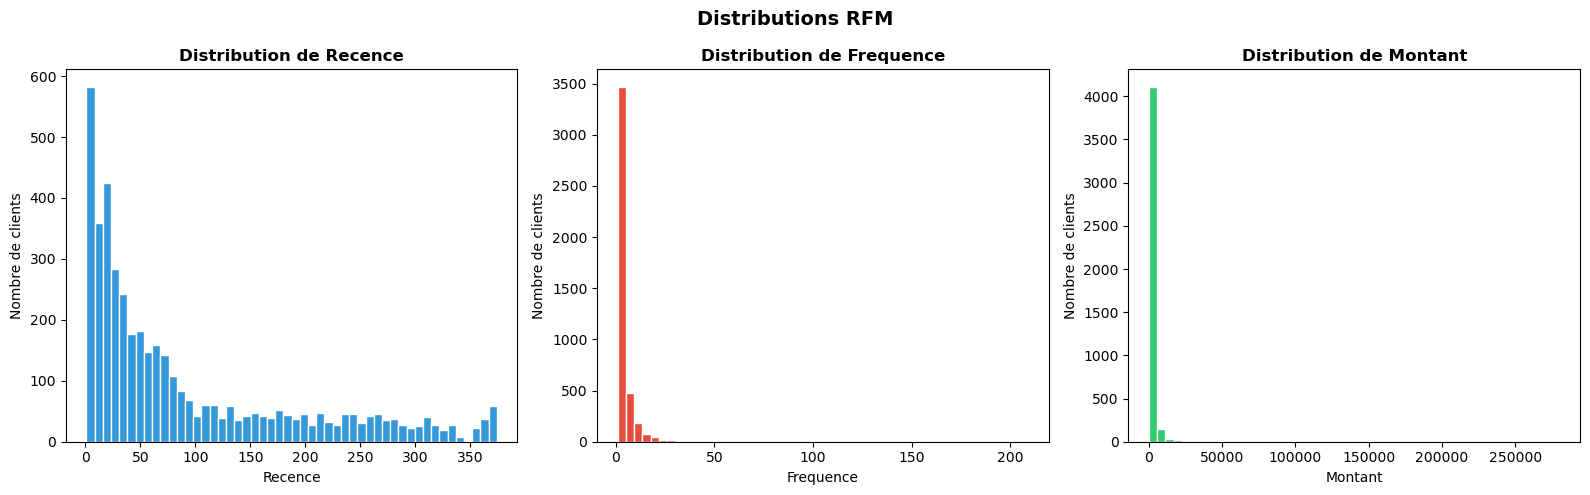

📐 Asymétrie (Skewness) :
   Recence      : 1.25
   Frequence    : 12.07
   Montant      : 19.32


In [11]:
# === CELLULE 10 : DISTRIBUTION DU MONTANT (Q7) ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = ['Recence', 'Frequence', 'Montant']
couleurs  = ['#3498db', '#e74c3c', '#2ecc71']

for ax, var, col in zip(axes, variables, couleurs):
    ax.hist(df_RFM[var], bins=50, color=col, edgecolor='white')
    ax.set_title(f'Distribution de {var}', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Nombre de clients')

plt.suptitle('Distributions RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calcul de l'asymétrie
print("📐 Asymétrie (Skewness) :")
for var in variables:
    skew = df_RFM[var].skew()
    print(f"   {var:<12} : {skew:.2f}")

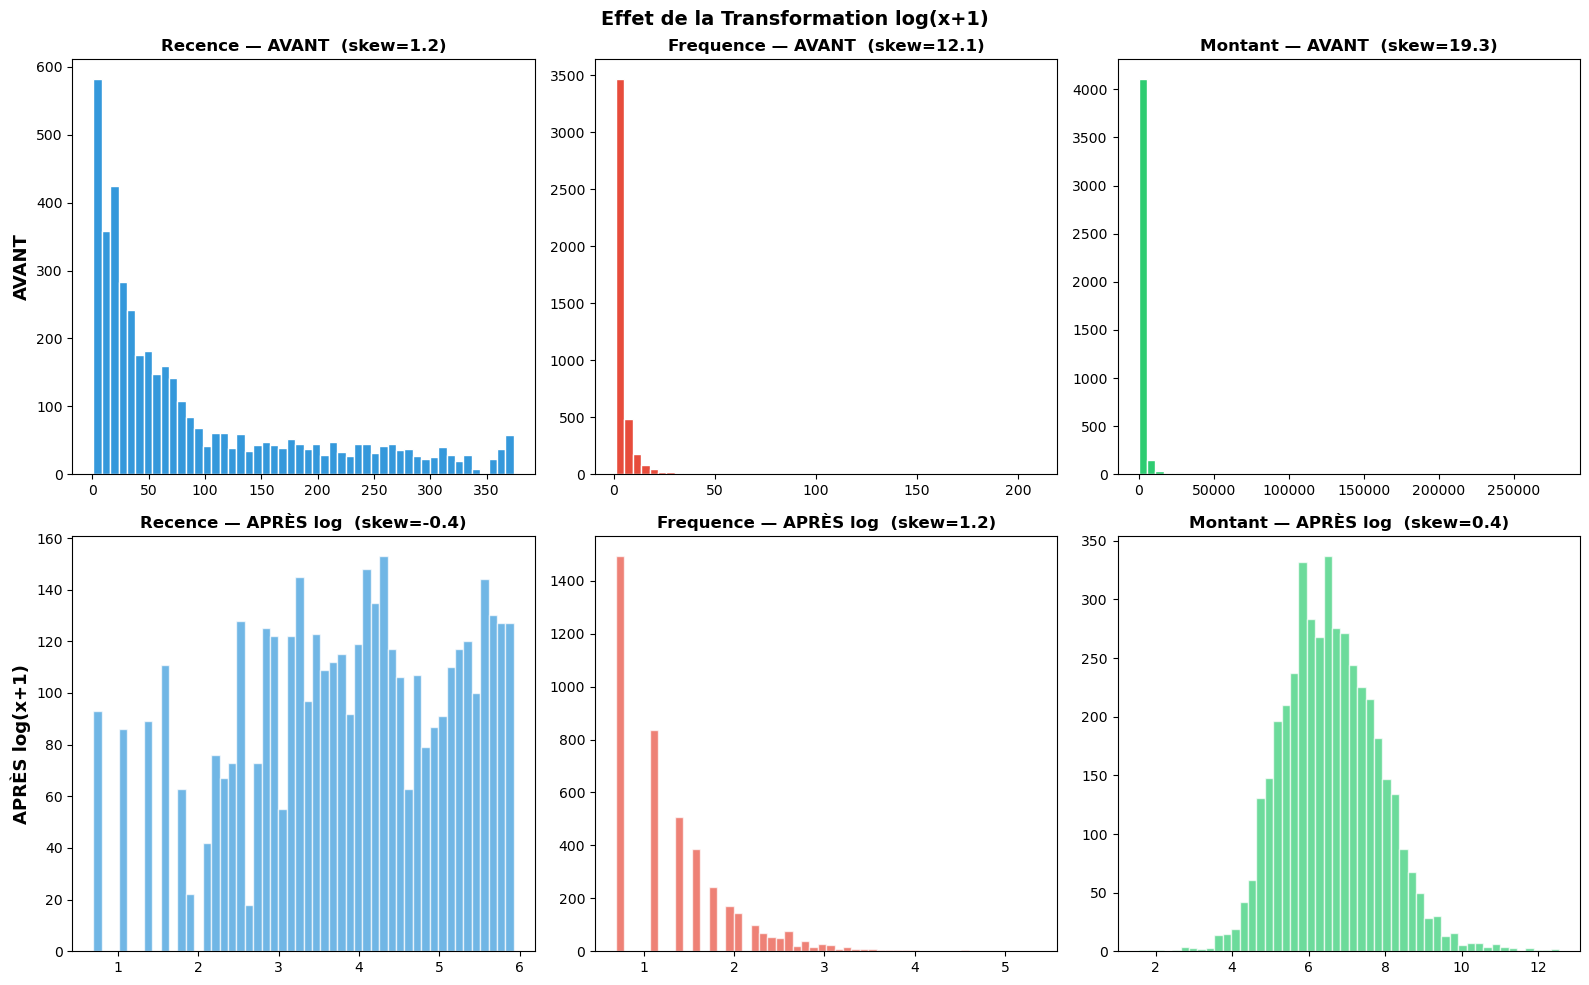

In [12]:
# === CELLULE 11 : TRANSFORMATION LOG (Q8) ===

df_RFM_log = df_RFM.copy()  # On garde l'original intact

# np.log1p = log(x + 1)
# Pourquoi +1 ? car log(0) = -infini → erreur !
df_RFM_log['Recence']   = np.log1p(df_RFM['Recence'])
df_RFM_log['Frequence'] = np.log1p(df_RFM['Frequence'])
df_RFM_log['Montant']   = np.log1p(df_RFM['Montant'])

# Visualisation avant/après
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
variables = ['Recence', 'Frequence', 'Montant']
couleurs  = ['#3498db', '#e74c3c', '#2ecc71']

for i, (var, col) in enumerate(zip(variables, couleurs)):
    # Ligne du haut = AVANT
    axes[0, i].hist(df_RFM[var], bins=50, color=col, edgecolor='white')
    axes[0, i].set_title(f'{var} — AVANT  (skew={df_RFM[var].skew():.1f})', fontweight='bold')
    
    # Ligne du bas = APRÈS
    axes[1, i].hist(df_RFM_log[var], bins=50, color=col, edgecolor='white', alpha=0.7)
    axes[1, i].set_title(f'{var} — APRÈS log  (skew={df_RFM_log[var].skew():.1f})', fontweight='bold')

axes[0,0].set_ylabel('AVANT', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('APRÈS log(x+1)', fontsize=13, fontweight='bold')

plt.suptitle('Effet de la Transformation log(x+1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# === CELLULE 12 : STANDARDISATION (Q9) ===

scaler = StandardScaler()
features = ['Recence', 'Frequence', 'Montant']

# fit_transform calcule la moyenne et l'écart-type,
# puis transforme : z = (x - moyenne) / écart_type
X = scaler.fit_transform(df_RFM_log[features])

# Vérification : moyenne ≈ 0, écart-type ≈ 1
X_df = pd.DataFrame(X, columns=features)
print("✅ Standardisation appliquée !")
print("\nVérification (moyenne doit être ≈ 0, std ≈ 1) :")
print(X_df.describe().round(3))

✅ Standardisation appliquée !

Vérification (moyenne doit être ≈ 0, std ≈ 1) :
        Recence  Frequence   Montant
count  4338.000   4338.000  4338.000
mean     -0.000     -0.000     0.000
std       1.000      1.000     1.000
min      -2.341     -0.955    -4.005
25%      -0.661     -0.955    -0.686
50%       0.090     -0.362    -0.062
75%       0.845      0.653     0.654
max       1.564      5.859     4.732


   k= 1  →  Inertie = 13,014.0
   k= 2  →  Inertie = 6,481.2
   k= 3  →  Inertie = 4,867.8
   k= 4  →  Inertie = 3,938.5
   k= 5  →  Inertie = 3,296.0
   k= 6  →  Inertie = 2,855.0
   k= 7  →  Inertie = 2,548.9
   k= 8  →  Inertie = 2,336.8
   k= 9  →  Inertie = 2,155.6
   k=10  →  Inertie = 1,999.9


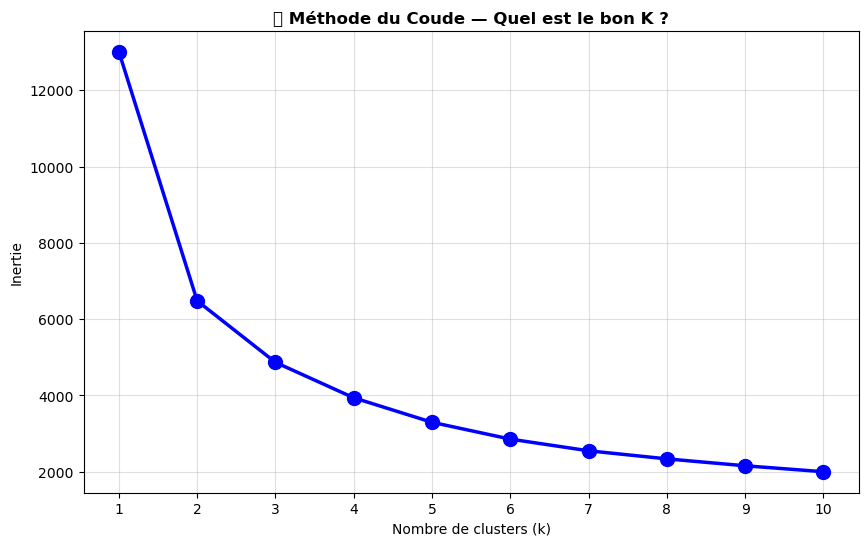

In [14]:
# === CELLULE 13 : MÉTHODE DU COUDE (Q10) ===

inerties = []

# On teste K de 1 à 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inerties.append(kmeans.inertia_)
    print(f"   k={k:2d}  →  Inertie = {kmeans.inertia_:,.1f}")

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inerties, 'bo-', linewidth=2.5, markersize=10)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('📐 Méthode du Coude — Quel est le bon K ?', fontweight='bold')
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.4)
plt.show()

In [15]:
# === CELLULE 14 : VALIDATION PAR SILHOUETTE SCORE (Q11) ===

print("📉 Variation de l'inertie entre chaque k :")
for i in range(1, len(inerties)):
    variation = inerties[i-1] - inerties[i]
    barre = '█' * int(variation / 500)
    print(f"   k={i} → k={i+1} : réduction de {variation:,.0f}  {barre}")

print("\n🔄 Calcul du Silhouette Score pour k=2 à 6...")
silhouettes = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouettes.append(score)
    print(f"   k={k}  →  Silhouette = {score:.4f}")

k_optimal = silhouettes.index(max(silhouettes)) + 2
print(f"\n🏆 Meilleur Silhouette Score : k={k_optimal}")

📉 Variation de l'inertie entre chaque k :
   k=1 → k=2 : réduction de 6,533  █████████████
   k=2 → k=3 : réduction de 1,613  ███
   k=3 → k=4 : réduction de 929  █
   k=4 → k=5 : réduction de 643  █
   k=5 → k=6 : réduction de 441  
   k=6 → k=7 : réduction de 306  
   k=7 → k=8 : réduction de 212  
   k=8 → k=9 : réduction de 181  
   k=9 → k=10 : réduction de 156  

🔄 Calcul du Silhouette Score pour k=2 à 6...
   k=2  →  Silhouette = 0.4329
   k=3  →  Silhouette = 0.3365
   k=4  →  Silhouette = 0.3371
   k=5  →  Silhouette = 0.3161
   k=6  →  Silhouette = 0.3133

🏆 Meilleur Silhouette Score : k=2


In [16]:
# === CELLULE 15 : MODÈLE K-MEANS FINAL (Q12) ===

K_FINAL = 2

kmeans_final = KMeans(
    n_clusters  = K_FINAL,
    init        = 'k-means++',  # Initialisation intelligente
    n_init      = 10,
    random_state= 42
)

# fit_predict = entraîne ET assigne chaque client à un cluster
df_RFM['Cluster'] = kmeans_final.fit_predict(X)

print(f"✅ Modèle entraîné avec k={K_FINAL}")
print(f"\n📊 Répartition des clients :")
for cluster, nb in df_RFM['Cluster'].value_counts().sort_index().items():
    pct = nb/len(df_RFM)*100
    barre = '█' * int(pct/2)
    print(f"   Cluster {cluster} : {nb:,} clients ({pct:.1f}%) {barre}")

✅ Modèle entraîné avec k=2

📊 Répartition des clients :
   Cluster 0 : 2,671 clients (61.6%) ██████████████████████████████
   Cluster 1 : 1,667 clients (38.4%) ███████████████████


In [17]:
# === CELLULE 16 : PROFIL DES CLUSTERS (Q13) ===

profil = df_RFM.groupby('Cluster').agg(
    Nb_clients    = ('CustomerID', 'count'),
    Recence_moy   = ('Recence',    'mean'),
    Frequence_moy = ('Frequence',  'mean'),
    Montant_moy   = ('Montant',    'mean')
).round(1)

print("📊 PORTRAIT MOYEN DE CHAQUE CLUSTER :")
display(profil)

📊 PORTRAIT MOYEN DE CHAQUE CLUSTER :


,Nb_clients,Recence_moy,Frequence_moy,Montant_moy
Cluster,,,,
0,2671,134.1,1.7,497.7
1,1667,25.9,8.4,4548.3


In [18]:
# === CELLULE 17 : NOMMAGE DES SEGMENTS (Q14) ===

# On crée un dictionnaire qui associe chaque numéro à un nom
noms = {
    1 : '🏆 Champions',
    0 : '⚠️ À Risque'
}

df_RFM['Segment'] = df_RFM['Cluster'].map(noms)

print("📊 Répartition finale des segments :")
for segment, nb in df_RFM['Segment'].value_counts().items():
    pct = nb/len(df_RFM)*100
    barre = '█' * int(pct/2)
    print(f"   {segment:<20} : {nb:,} clients ({pct:.1f}%) {barre}")

📊 Répartition finale des segments :
   ⚠️ À Risque          : 2,671 clients (61.6%) ██████████████████████████████
   🏆 Champions          : 1,667 clients (38.4%) ███████████████████


In [25]:
# === CELLULE 18 : STRATÉGIES MARKETING (Q15) ===

strategies = {
    '🏆 Champions' : {
        'profil'   : 'Récents, fréquents, gros dépensiers',
        'objectif' : 'Les fidéliser et les faire se sentir VIP',
        'actions'  : [
            'Message exclusif : "Vous avez accès en avant-première à notre nouvelle collection"',
            'Programme VIP avec points de fidélité doublés',
            'Service client prioritaire dédié',
            'Invitation à des ventes privées réservées aux meilleurs clients'
        ]
    },
    '⚠️ À Risque' : {
        'profil'   : 'Inactifs depuis longtemps',
        'objectif' : 'Les réactiver avant de les perdre définitivement',
        'actions'  : [
            'Email personnalisé : "Vous nous manquez ! Pour votre retour, on vous offre un cadeau gratuit"',
            'Cadeau gratuit avec la prochaine commande',
            'Réduction spéciale sur leur catégorie préférée',
            'Enquête rapide pour comprendre pourquoi ils sont partis'
        ]
    }
}

for segment, data in strategies.items():
    print(f"\n{'='*55}")
    print(f"  {segment}")
    print(f"{'='*55}")
    print(f"  Profil   : {data['profil']}")
    print(f"  Objectif : {data['objectif']}")
    print(f"  Actions  :")
    for action in data['actions']:
        print(f"     • {action}")


  🏆 Champions
  Profil   : Récents, fréquents, gros dépensiers
  Objectif : Les fidéliser et les faire se sentir VIP
  Actions  :
     • Message exclusif : "Vous avez accès en avant-première à notre nouvelle collection"
     • Programme VIP avec points de fidélité doublés
     • Service client prioritaire dédié
     • Invitation à des ventes privées réservées aux meilleurs clients

  ⚠️ À Risque
  Profil   : Inactifs depuis longtemps
  Objectif : Les réactiver avant de les perdre définitivement
  Actions  :
     • Email personnalisé : "Vous nous manquez ! Pour votre retour, on vous offre un cadeau gratuit"
     • Cadeau gratuit avec la prochaine commande
     • Réduction spéciale sur leur catégorie préférée
     • Enquête rapide pour comprendre pourquoi ils sont partis


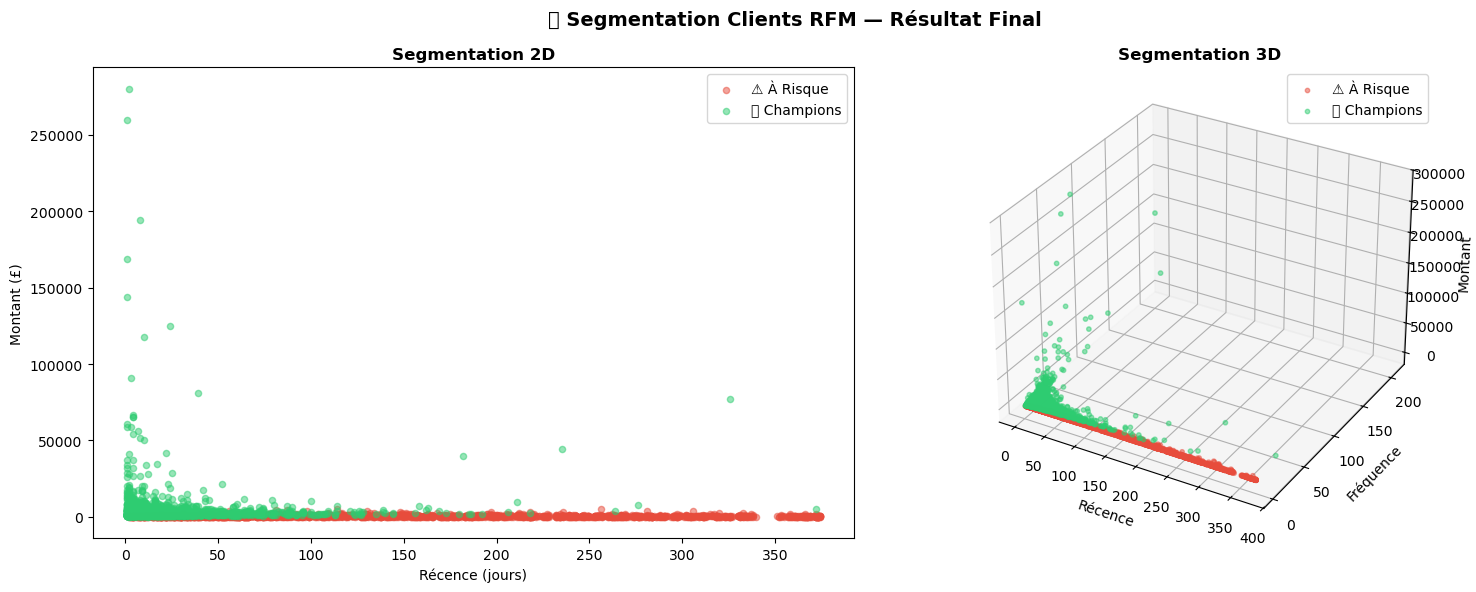

✅ Visualisation sauvegardée !


In [27]:
# === CELLULE 19 : VISUALISATION FINALE (2D et 3D) ===

fig = plt.figure(figsize=(16, 6))

couleurs = {0: '#e74c3c', 1: '#2ecc71'}
noms_seg = {0: '⚠️ À Risque', 1: '🏆 Champions'}

# --- Graphique 2D : Récence vs Montant ---
ax1 = fig.add_subplot(1, 2, 1)
for cluster in [0, 1]:
    mask = df_RFM['Cluster'] == cluster
    ax1.scatter(
        df_RFM.loc[mask, 'Recence'],
        df_RFM.loc[mask, 'Montant'],
        c=couleurs[cluster],
        label=noms_seg[cluster],
        alpha=0.5, s=20
    )
ax1.set_xlabel('Récence (jours)')
ax1.set_ylabel('Montant (£)')
ax1.set_title('Segmentation 2D', fontweight='bold')
ax1.legend()

# --- Graphique 3D : R, F, M ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for cluster in [0, 1]:
    mask = df_RFM['Cluster'] == cluster
    ax2.scatter(
        df_RFM.loc[mask, 'Recence'],
        df_RFM.loc[mask, 'Frequence'],
        df_RFM.loc[mask, 'Montant'],
        c=couleurs[cluster],
        label=noms_seg[cluster],
        alpha=0.5, s=10
    )
ax2.set_xlabel('Récence')
ax2.set_ylabel('Fréquence')
ax2.set_zlabel('Montant')
ax2.set_title('Segmentation 3D', fontweight='bold')
ax2.legend()

plt.suptitle('🎯 Segmentation Clients RFM — Résultat Final',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/visualisation_finale.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisation sauvegardée !")